In [1]:
import os
import gc
import time
import glob
from datetime import datetime
import numpy as np
from numpy.matlib import repmat
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
from netCDF4 import num2date
import xarray as xr
import pyart
import radarlib as rlib
from pyhail import hdr, hsda, mesh_ppi, mesh_grid

from urllib.parse import urlencode
import re

# Custom modules
import radar_plot_config as rpc # radar plotting
from download_nexrad import download_nexrad_from_filtered_counts, _expand_radar_sites # radar download

##############################################
# METR 5683 - Weather Radar Applications
# Final Project
# Author: Jacob Widanski
# Date: 9 May 2026
##############################################


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
# Radar test
radar_dir = r"C:\Users\wida0001\Documents\Courses\Weather Radar Applications\Data\NEXRAD"
#filepath=r"C:\Users\wida0001\Downloads\NOP420130519_213700_V06\NOP420130519_213700_V06"

file1=r"KTLX20130530_214603_V06"
file2=r"DAN120130530_214838_V06"
file3=r"TOKC20230419_225611_V08"


KTLX = pyart.io.read(os.path.join(radar_dir, file1))
KCRI = pyart.io.read(os.path.join(radar_dir, file2))
TOKC = pyart.io.read(os.path.join(radar_dir, file3))

KTLX.info()
list(KTLX.fields)

altitude:
	data: <ndarray of type: float64 and shape: (1,)>
	long_name: Altitude
	standard_name: Altitude
	units: meters
	positive: up
altitude_agl: None
antenna_transition: None
azimuth:
	data: <ndarray of type: float64 and shape: (8280,)>
	units: degrees
	standard_name: beam_azimuth_angle
	long_name: azimuth_angle_from_true_north
	axis: radial_azimuth_coordinate
	comment: Azimuth of antenna relative to true north
elevation:
	data: <ndarray of type: float32 and shape: (8280,)>
	units: degrees
	standard_name: beam_elevation_angle
	long_name: elevation_angle_from_horizontal_plane
	axis: radial_elevation_coordinate
	comment: Elevation of antenna relative to the horizontal plane
fields:
	cross_correlation_ratio:
		data: <ndarray of type: float32 and shape: (8280, 1832)>
		units: ratio
		standard_name: cross_correlation_ratio_hv
		long_name: Cross correlation_ratio (RHOHV)
		valid_max: 1.0
		valid_min: 0.0
		coordinates: elevation azimuth range
		_FillValue: -9999.0
	differential_phase:
		

['cross_correlation_ratio',
 'differential_phase',
 'spectrum_width',
 'velocity',
 'reflectivity',
 'differential_reflectivity']

In [3]:
print('KTLX has ', KTLX.range['data'].shape, ' gates')
print('KTLX has ', KTLX.azimuth['data'].shape, ' gates')
print('Units of time is ', KTLX.time['units'])
print('Latitude is',KTLX.latitude['data'])
print('Longitude is',KTLX.longitude['data'])
print('Radar name is',KTLX.metadata['instrument_name'])
print('Collection started at ', num2date(KTLX.time['data'][0],KTLX.time['units'] ))
print('Collection ended at ', num2date(KTLX.time['data'][-1],KTLX.time['units'] ))

KTLX has  (1832,)  gates
KTLX has  (8280,)  gates
Units of time is  seconds since 2013-05-30T21:46:03Z
Latitude is [35.3330574]
Longitude is [-97.27748108]
Radar name is KTLX
Collection started at  2013-05-30 21:46:03.809000
Collection ended at  2013-05-30 21:50:31.023000


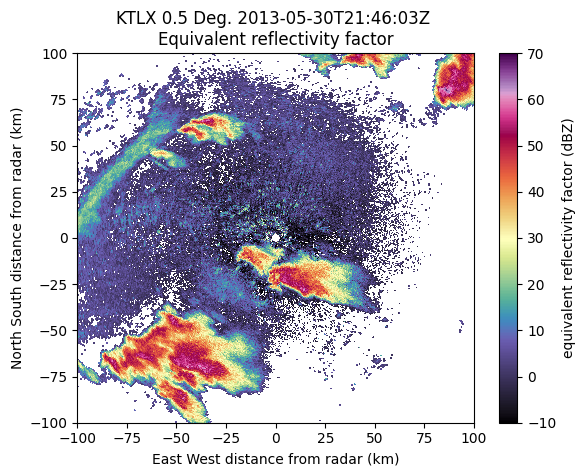

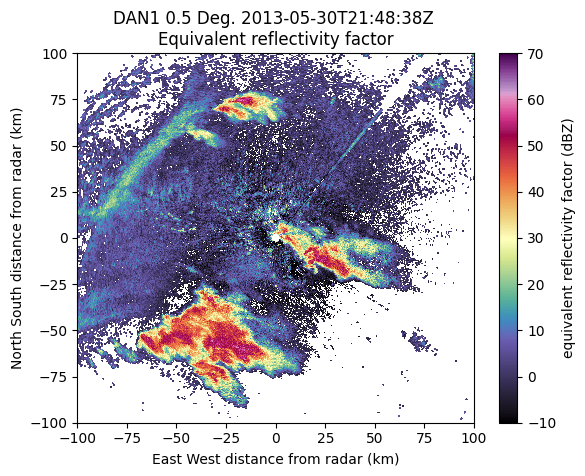

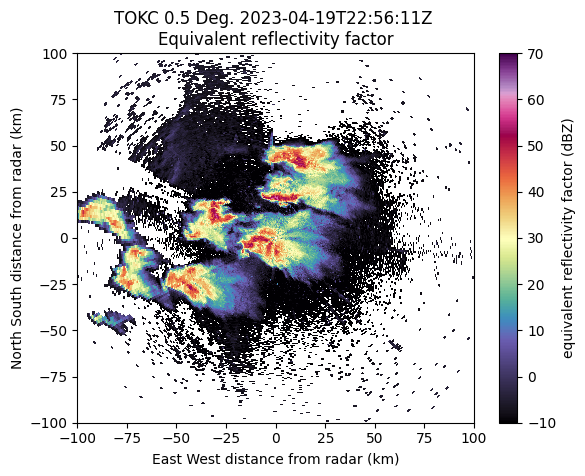

In [4]:
#Initialize a Display object
display1 = pyart.graph.RadarDisplay(KTLX)

display1.plot("reflectivity", #Field Name
    0, #Scan Number
    vmin=-10, #Minimum value to display
    vmax=70, #Maximum value to display
    cmap='ChaseSpectral') #Set colormap
display1.set_limits((-100,100),(-100,100)) #Set limits
plt.show()

#Initialize a Display object
display2 = pyart.graph.RadarDisplay(KCRI)

display2.plot("reflectivity", #Field Name
    0, #Scan Number
    vmin=-10, #Minimum value to display
    vmax=70, #Maximum value to display
    cmap='ChaseSpectral') #Set colormap
display2.set_limits((-100,100),(-100,100)) #Set limits
plt.show()

display3 = pyart.graph.RadarDisplay(TOKC)

display3.plot("reflectivity", #Field Name
    0, #Scan Number
    vmin=-10, #Minimum value to display
    vmax=70, #Maximum value to display
    cmap='ChaseSpectral') #Set colormap
display3.set_limits((-100,100),(-100,100)) #Set limits
plt.show()

In [5]:
# Create plot depicting all SHAVE and Storm Data reports within the radar domain (with lines depicting the spatial domain for DDA)
# Hail report database:
# * SHAVE (2013-2015; 1)
# * Storm Data (2013-2025; 2)
# * mPing (3) / Storm Data (Elmore et al. 2022; 2013-2020)

# 1. Curate hail reports database into a single CSV
base_dir = r"C:\Users\wida0001\Documents\Courses\Weather Radar Applications\Data\Project"

### SHAVE ###
SHAVE_reports = pd.read_csv(os.path.join(base_dir, 'SHAVE.csv'))

# Filter to OUN
SHAVE_reports = SHAVE_reports[SHAVE_reports['cwa'] == 'OUN'] 

# Use measured max ('max meas') if available, otherwise use estimated max ('max est')
SHAVE_reports['max_diameter_mm'] = SHAVE_reports.apply(lambda row: row['max meas'] if not pd.isna(row['max meas']) else row['max est'], axis=1)
SHAVE_reports['max_diameter_mm'] = SHAVE_reports['max_diameter_mm'] * 25.4 # Convert inches to mm

# Use mean time if (end time - start time) > 0
start_datetimes = pd.to_datetime(SHAVE_reports['start_datetime'])
end_datetimes = pd.to_datetime(SHAVE_reports['end_datetime'])

time_deltas = end_datetimes - start_datetimes
mean_times = start_datetimes + time_deltas / 2
SHAVE_reports['time'] = mean_times

SHAVE_reports = SHAVE_reports[SHAVE_reports['time'].dt.year >= 2013] # Temporal filter

SHAVE_reports['source'] = 1

# Keep core columns
shave_columns = ['time', 'lat', 'lon', 'max_diameter_mm', 'source']
SHAVE_reports = SHAVE_reports[shave_columns].sort_values('time').reset_index(drop=True)
print("SHAVE: ", SHAVE_reports.head())

### mPing (Elmore et al. 2022) ###
# source = 1 for mPing, 2 for Storm Data
mping = pd.read_csv(os.path.join(base_dir, 'mPING_Storm_Data.csv'))
mping = mping[mping['source'] == 1] # Filter to mPing reports only
mping['source'] = 3 # Update source to 3 for mPing

# Fix observation time
mping['obtime'] = mping['obtime'].str.replace(' AM', '')
mping['time'] = pd.to_datetime(mping['obtime'], format='%m/%d/%Y %H:%M:%S')
mping.rename(columns={'hailsize.mm': 'max_diameter_mm'}, inplace=True)

columns = ['time', 'lat', 'lon', 'max_diameter_mm', 'source']
mping = mping[columns].sort_values('time').reset_index(drop=True)
print("mPing: ", mping.head())

### Storm Data ###
# Concatenate all years (2013-2025)
storm_data = glob.glob(os.path.join(base_dir, 'StormEvents_details-ftp_v1.0_d20*.csv'))
storm_data = pd.concat((pd.read_csv(file) for file in storm_data), ignore_index=True)

# Filter by OUN and hail events
storm_data = storm_data[(storm_data['WFO'] == 'OUN') & (storm_data['EVENT_TYPE'] == 'Hail')]

# Convert times from local time to UTC (+6)
storm_data['time'] = pd.to_datetime(storm_data['BEGIN_DATE_TIME']) + pd.Timedelta(hours=6)

storm_data.rename(columns={'BEGIN_LAT': 'lat', 'BEGIN_LON': 'lon', 'MAGNITUDE': 'max_diameter_mm'}, inplace=True)
storm_data['max_diameter_mm'] = storm_data['max_diameter_mm'] * 25.4 # Convert inches to mm
storm_data['source'] = 2

columns = ['time', 'lat', 'lon', 'max_diameter_mm', 'source']
storm_data = storm_data[columns].sort_values('time').reset_index(drop=True)
print("Storm Data: ", storm_data.head())

### Combine all reports into a single DataFrame ###
OUN_hail = pd.concat([SHAVE_reports, mping, storm_data], ignore_index=True).sort_values('time').reset_index(drop=True)
OUN_hail = OUN_hail[OUN_hail['max_diameter_mm'] >= 0] # Remove negative values
print("All reports: ", OUN_hail.head())
OUN_hail.to_csv(os.path.join(base_dir, 'OUN_hail_reports_2013_2025.csv'), index=False)

SHAVE:                   time        lat        lon  max_diameter_mm  source
0 2013-03-29 12:10:00  35.553487 -97.798472           22.352       1
1 2013-03-29 23:22:00  35.578510 -97.883130           44.450       1
2 2013-03-29 23:50:00  35.565126 -97.771114           31.750       1
3 2013-03-29 23:50:00  35.585810 -97.849557           44.450       1
4 2013-03-29 23:50:00  35.579194 -97.816756           25.400       1
mPing:                   time        lat         lon  max_diameter_mm  source
0 2013-01-11 23:23:00  42.323200 -122.837670            25.40       3
1 2013-01-12 21:13:00  35.268220  -95.575030             6.35       3
2 2013-01-13 04:07:00  33.087505  -97.050255             6.35       3
3 2013-01-13 04:17:00  33.177700  -96.909070             6.35       3
4 2013-01-13 19:41:00  30.699120  -97.720410             6.35       3
Storm Data:                   time    lat    lon  max_diameter_mm  source
0 2013-01-29 11:10:00  35.51 -98.97             25.4       2
1 2013-01-29 11

[35.2474]
[-97.5395]
{'KTLX': (35.33305740356445, -97.27748107910156), 'KCRI': (35.23833465576172, -97.45999908447266)}


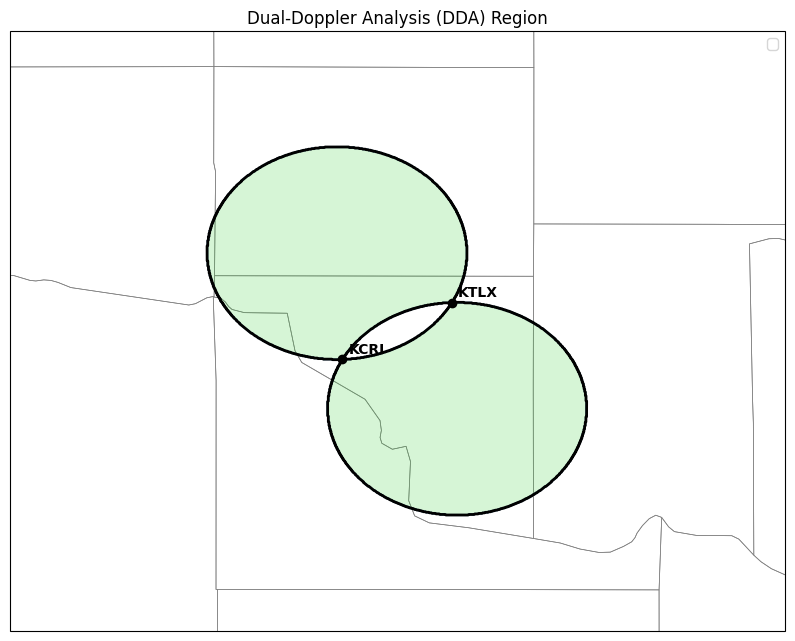

In [6]:
### Calculate region of dual-Doppler coverage (lobe) ###

from pyproj import Proj, Transformer
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
print(TOKC.latitude['data'])
print(TOKC.longitude['data'])

# Update TOKC location
TOKC.latitude['data'] = np.array([35.276095099831174])
TOKC.longitude['data'] = np.array([-97.50997083450969])

# ---------------------------
# 1) Radar locations
# ---------------------------
radars = {
    "KTLX": (float(KTLX.latitude["data"][0]), float(KTLX.longitude["data"][0])),
    "KCRI": (float(KCRI.latitude["data"][0]), float(KCRI.longitude["data"][0])),
    #"TOKC": (float(TOKC.latitude["data"][0]), float(TOKC.longitude["data"][0])),
}

print(radars)

# Projection center = mean of radar locations
center_lat = np.mean([v[0] for v in radars.values()])
center_lon = np.mean([v[1] for v in radars.values()])
proj = Proj(proj="aeqd", lat_0=center_lat, lon_0=center_lon, datum="WGS84")
transformer = Transformer.from_proj("epsg:4326", proj, always_xy=True)

# Convert radars to projected x/y (meters)
radar_xy = {}
for name, (lat, lon) in radars.items():
    x, y = transformer.transform(lon, lat)
    radar_xy[name] = (x, y)

# ---------------------------
# 2) Build grid (use 1000 for true 1-km spacing)
# ---------------------------
xs = [xy[0] for xy in radar_xy.values()]
ys = [xy[1] for xy in radar_xy.values()]

buffer_m = 50000
min_x, max_x = min(xs) - buffer_m, max(xs) + buffer_m
min_y, max_y = min(ys) - buffer_m, max(ys) + buffer_m

dx = 100  # 100 m
dy = 100
grid_x, grid_y = np.meshgrid(
    np.arange(min_x, max_x + dx, dx),
    np.arange(min_y, max_y + dy, dy)
)

# ---------------------------
# 3) Pair-angle masks
# ---------------------------
def pair_angle_mask(xa, ya, xb, yb, gx, gy, angle_thr_deg):
    va_x = gx - xa
    va_y = gy - ya
    vb_x = gx - xb
    vb_y = gy - yb

    na = np.sqrt(va_x**2 + va_y**2)
    nb = np.sqrt(vb_x**2 + vb_y**2)

    # Avoid divide-by-zero exactly at radar pixels
    na = np.where(na == 0, np.nan, na)
    nb = np.where(nb == 0, np.nan, nb)

    cosang = (va_x * vb_x + va_y * vb_y) / (na * nb)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang = np.degrees(np.arccos(cosang))

    return (ang >= angle_thr_deg) & (ang <= (180 - angle_thr_deg))

# Create mask for desired angle range (ensure that interbeam angle is between 30 and 150 degrees)
#angle = 18.19 # (cos^(-1)(0.95))
angle_thr = 30

# mask = (angles >= angle) & (angles <= (180 - angle))
x_tlx, y_tlx = radar_xy["KTLX"]
x_cri, y_cri = radar_xy["KCRI"]
# x_okc, y_okc = radar_xy["TOKC"]

mask_tlx_cri = pair_angle_mask(x_tlx, y_tlx, x_cri, y_cri, grid_x, grid_y, angle_thr)
# mask_tlx_okc = pair_angle_mask(x_tlx, y_tlx, x_okc, y_okc, grid_x, grid_y, angle_thr)
# mask_cri_okc = pair_angle_mask(x_cri, y_cri, x_okc, y_okc, grid_x, grid_y, angle_thr)


# Combined DDA region: valid if ANY pair is valid
mask = mask_tlx_cri
# mask = mask_tlx_cri | mask_tlx_okc | mask_cri_okc


# Plot the mask
lon_grid, lat_grid = transformer.transform(grid_x, grid_y, direction='INVERSE')

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.coastlines(resolution='10m', linewidth=0.5)

# Add counties (Natural Earth, 10m)
counties = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_2_counties',
    scale='10m',
    facecolor='none',
    edgecolor='gray',
    linewidth=0.5
)
ax.add_feature(counties, zorder=1)

#plt.pcolormesh(lon_grid, lat_grid, mask, cmap='Greens', alpha=0.5)
# Individual pair boundaries
ax.contour(lon_grid, lat_grid, mask_tlx_cri.astype(float), levels=[0.5], colors="tab:blue", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
# ax.contour(lon_grid, lat_grid, mask_tlx_okc.astype(float), levels=[0.5], colors="tab:orange", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)
# ax.contour(lon_grid, lat_grid, mask_cri_okc.astype(float), levels=[0.5], colors="tab:green", linewidths=1.5, transform=ccrs.PlateCarree(), zorder=2)

# Combined region fill + boundary
ax.contourf(lon_grid, lat_grid, mask.astype(float), levels=[0.5, 1.5], colors=["limegreen"], alpha=0.2, transform=ccrs.PlateCarree(), zorder=1)
ax.contour(lon_grid, lat_grid, mask.astype(float), levels=[0.5], colors="black", linewidths=2.0, transform=ccrs.PlateCarree(), zorder=3)

# Plot radar locations and label them
# ax.plot(KTLX.longitude['data'][0], KTLX.latitude['data'][0], 'ro', markersize=8, label='KTLX')
# ax.plot(KCRI.longitude['data'][0], KCRI.latitude['data'][0], 'bo', markersize=8, label='KCRI')
# ax.text(KTLX.longitude['data'][0], KTLX.latitude['data'][0], ' KTLX', color='red', fontsize=12, weight='bold')
# ax.text(KCRI.longitude['data'][0], KCRI.latitude['data'][0], ' KCRI', color='blue', fontsize=12, weight='bold')
# Radar markers
for name, (lat, lon) in radars.items():
    ax.plot(lon, lat, "ko", markersize=6, transform=ccrs.PlateCarree(), zorder=4)
    ax.text(lon + 0.01, lat + 0.01, name, fontsize=10, weight="bold", transform=ccrs.PlateCarree(), zorder=5)

ax.set_title('Dual-Doppler Analysis (DDA) Region')
ax.legend(loc='upper right')
ax.set_extent([lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()], crs=ccrs.PlateCarree())
plt.show()
fig.savefig(f'DDA_KCRI_KTLX_{angle_thr}.png', dpi=300, bbox_inches='tight')

In [7]:
from matplotlib.path import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If using TOKC reports, filter to 2020-2025 to match radar data period
TOKC_filter = False
if TOKC_filter:
    OUN_hail = OUN_hail[OUN_hail['time'].dt.year >= 2020]

# A) Build lobe boundary in projected x/y (same coords used for angle calc)
cs_xy = plt.contour(grid_x, grid_y, mask.astype(float), levels=[0.5])
segments_xy = cs_xy.allsegs[0]
plt.close()

# B) Convert report points to projected x/y
rx, ry = transformer.transform(OUN_hail["lon"].values, OUN_hail["lat"].values)
report_pts = np.column_stack([rx, ry])

# C) Point-in-polygon test against all lobe polygons
inside = np.zeros(len(OUN_hail), dtype=bool)
for seg in segments_xy:
    if len(seg) < 3:
        continue
    poly = Path(seg)
    inside |= poly.contains_points(report_pts)

dda_region_reports = OUN_hail.loc[inside].copy()
print(f"Inside DDA: {inside.sum()} / {len(inside)}")

Inside DDA: 3893 / 85418


In [8]:
### Summary statistics ###
print("Report counts by source:")
print(OUN_hail['source'].value_counts())
# Note: mPing reports not filtered by OUN

# Find dates with combined Storm Data + SHAVE report counts > 10
#OUN_hail = OUN_hail[OUN_hail['source'].isin([1, 2])].copy()
OUN_hail['date'] = OUN_hail['time'].dt.date

# 1. Project report locations to x/y
report_x, report_y = transformer.transform(OUN_hail['lon'].values, OUN_hail['lat'].values)

# 2. Find nearest grid cell for each report
ix = np.clip(np.round((report_x - grid_x[0,0]) / (grid_x[0,1] - grid_x[0,0])).astype(int), 0, grid_x.shape[1]-1)
iy = np.clip(np.round((report_y - grid_y[0,0]) / (grid_y[1,0] - grid_y[0,0])).astype(int), 0, grid_y.shape[0]-1)

# 3. Mask: keep only reports inside the DDA region
inside_mask = mask[iy, ix]
dda_region_reports = OUN_hail[inside_mask].copy()

print(dda_region_reports['lat'].min(), dda_region_reports['lat'].max())
print(dda_region_reports['lon'].min(), dda_region_reports['lon'].max())

# Count by date and source
counts = dda_region_reports.groupby(['date', 'source']).size().unstack(fill_value=0)
counts['total'] = counts.sum(axis=1)
filtered = counts[counts['total'] >= 10]

print("Date: report count | Storm Data count, SHAVE count, mPing count | (earliest, latest)")
for date, row in filtered.iterrows():
    mping_count = row.get(3, 0)
    storm_count = row.get(2, 0)
    shave_count = row.get(1, 0)
    total = storm_count + shave_count + mping_count
    # Get times for this date and these sources
    day_reports = dda_region_reports[dda_region_reports['date'] == date]
    earliest = day_reports['time'].min().strftime('%H:%M:%S')
    latest = day_reports['time'].max().strftime('%H:%M:%S')
    print(f"{date}: {total} | {storm_count}, {shave_count}, {mping_count} | ({earliest}, {latest})")

# Get top 10 dates by total count, Storm Data count, and SHAVE count
top_dates_all = counts.sort_values('total', ascending=False).head(10)
top_dates_stormdata = counts.sort_values(2, ascending=False).head(10)
top_dates_shave = counts.sort_values(1, ascending=False).head(10)
top_dates_shave_stormdata = counts.sort_values([1, 2], ascending=False).head(10)

for top_dates, source in [(top_dates_all, "combined"), (top_dates_stormdata, "Storm Data"), (top_dates_shave, "SHAVE"), (top_dates_shave_stormdata, "SHAVE + Storm Data")]:
    print(f"\nTop 10 dates with highest {source} counts:")
    for date, row in top_dates.iterrows():
        mping_count = row.get(3, 0)
        storm_count = row.get(2, 0)
        shave_count = row.get(1, 0)
        total = storm_count + shave_count + mping_count
        # Get times for this date and these sources
        day_reports = dda_region_reports[dda_region_reports['date'] == date]
        earliest = day_reports['time'].min().strftime('%H:%M:%S')
        latest = day_reports['time'].max().strftime('%H:%M:%S')
        print(f"{date}: {total} | {storm_count}, {shave_count}, {mping_count} | ({earliest}, {latest})")


Report counts by source:
source
3    79840
2     5220
1      358
Name: count, dtype: int64
35.0 35.59067
-97.68159018766238 -97.06
Date: report count | Storm Data count, SHAVE count, mPing count | (earliest, latest)
2013-03-09: 11 | 0, 0, 11 | (20:54:00, 21:09:00)
2013-03-31: 64 | 10, 0, 54 | (07:50:00, 10:46:00)
2013-04-18: 44 | 3, 0, 41 | (00:10:00, 03:22:00)
2013-04-23: 12 | 4, 0, 8 | (04:40:00, 05:13:00)
2013-04-27: 61 | 2, 0, 59 | (01:45:00, 03:32:00)
2013-05-09: 18 | 1, 0, 17 | (02:01:00, 03:14:00)
2013-05-19: 57 | 10, 18, 29 | (22:02:00, 23:59:00)
2013-05-23: 11 | 1, 0, 10 | (11:42:00, 13:46:00)
2013-05-30: 30 | 4, 26, 0 | (20:45:00, 22:11:00)
2013-06-01: 30 | 8, 0, 22 | (00:19:00, 04:27:00)
2014-03-02: 16 | 0, 0, 16 | (18:16:00, 20:03:00)
2014-04-07: 30 | 0, 0, 30 | (21:09:00, 23:44:00)
2014-04-13: 225 | 7, 0, 218 | (19:34:00, 22:23:00)
2014-04-27: 31 | 1, 0, 30 | (10:33:00, 13:33:00)
2014-05-08: 24 | 1, 0, 23 | (02:51:00, 05:32:00)
2014-06-08: 48 | 5, 0, 43 | (06:26:00, 06:58:

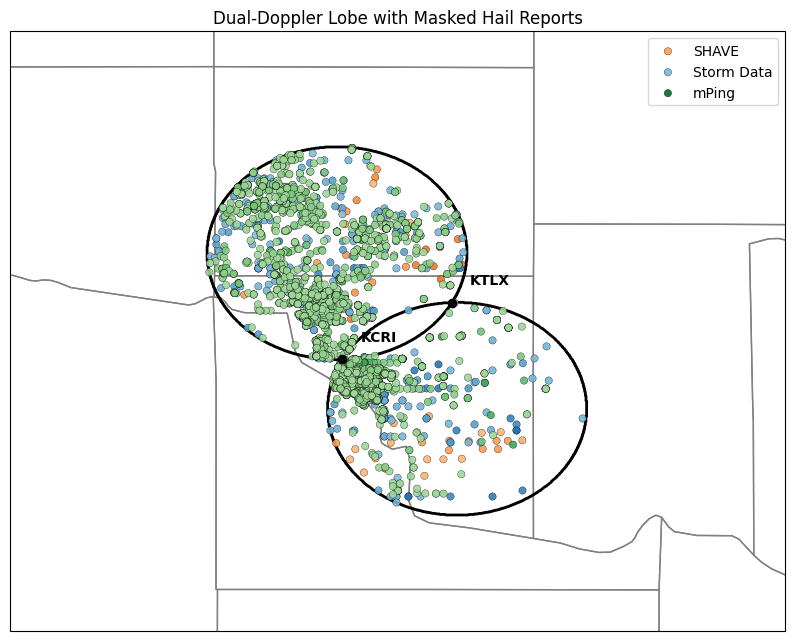

In [9]:
plot_reports = dda_region_reports.copy()

# Source styling
source_cmaps = {
    1: plt.cm.Oranges,  # SHAVE
    2: plt.cm.Blues,    # Storm Data
    3: plt.cm.Greens    # mPing
}
source_labels = {
    1: "SHAVE",
    2: "Storm Data",
    3: "mPing"
}

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

# Map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.coastlines(resolution="10m", linewidth=0.5)

counties = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_2_counties",
    scale="10m",
    facecolor="none",
    edgecolor="gray",
    linewidth=1
)
ax.add_feature(counties, zorder=1)

# Lobe depiction (use contour for smooth boundary)
ax.contour(
    lon_grid, lat_grid, mask.astype(float),
    levels=[0.5], colors="black", linewidths=2,
    transform=ccrs.PlateCarree(), zorder=2
)

# Radar points + labels
# ax.plot(lon1, lat1, "ro", markersize=8, transform=ccrs.PlateCarree(), zorder=4)
# ax.plot(lon2, lat2, "bo", markersize=8, transform=ccrs.PlateCarree(), zorder=4)
# ax.text(lon1 + 0.03, lat1 + 0.03, "KTLX", color="red", fontsize=11, weight="bold",
#         transform=ccrs.PlateCarree(), zorder=5)
# ax.text(lon2 + 0.03, lat2 + 0.03, "KCRI", color="blue", fontsize=11, weight="bold",
#         transform=ccrs.PlateCarree(), zorder=5)

vmin = plot_reports["max_diameter_mm"].min()
vmax = plot_reports["max_diameter_mm"].max()
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

for src in sorted(plot_reports["source"].dropna().unique()):
    src = int(src)
    subset = plot_reports[plot_reports["source"] == src].copy()
    cmap = source_cmaps.get(src, plt.cm.Greys)

    # Larger hail -> darker shade (sample upper range of cmap)
    color_vals = 0.35 + 0.60 * norm(subset["max_diameter_mm"].values)
    point_colors = cmap(color_vals)

    ax.scatter(
        subset["lon"], subset["lat"],
        s=28, c=point_colors,
        label=source_labels.get(src, f"Source {src}"),
        edgecolors="black", linewidths=0.25, alpha=0.9,
        transform=ccrs.PlateCarree(), zorder=4
    )

for name, (lat, lon) in radars.items():
    ax.plot(lon, lat, "ko", markersize=6, transform=ccrs.PlateCarree(), zorder=4)
    ax.text(lon + 0.03, lat + 0.03, name, fontsize=10, weight="bold", transform=ccrs.PlateCarree(), zorder=5)

ax.set_extent([lon_grid.min(), lon_grid.max(), lat_grid.min(), lat_grid.max()],
              crs=ccrs.PlateCarree())
ax.set_title("Dual-Doppler Lobe with Masked Hail Reports")
ax.legend(loc="upper right")
plt.show()
fig.savefig(os.path.join(base_dir, f"DDA_lobe_hail_reports_KTLX_KCRI_{angle_thr}.png"), dpi=300, bbox_inches='tight')

In [10]:
### Extract NEXRAD data for selected cases
dates = [
    "2013-05-19", "2013-05-30",
    "2023-04-19", "2023-04-20", "2025-05-25",
    "2020-08-31", "2020-05-04", "2024-09-24",
]
radar_sites = ["KTLX", "KCRI", "TOKC"]
radar_dir = os.path.join(base_dir, "NEXRAD")

windows, manifest = download_nexrad_from_filtered_counts(
    filtered_counts=filtered,
    dda_region_reports=dda_region_reports,
    selected_dates=dates,
    radar_sites=radar_sites,
    out_dir=radar_dir,
    skip_existing=True,
    dry_run=True,  # Set to False for actual downloading
    verbose=True,
)

print("\nTime windows derived from masked DDA reports:")
display(windows)
print("\nDownload manifest (preview):")
display(manifest.head(20))

[KTLX/KTLX] 2013-05-19 22:02:03 -> exists_skipped: KTLX20130519_220203_V06.gz
[KTLX/KTLX] 2013-05-19 22:06:17 -> exists_skipped: KTLX20130519_220617_V06.gz
[KTLX/KTLX] 2013-05-19 22:10:33 -> exists_skipped: KTLX20130519_221033_V06.gz
[KTLX/KTLX] 2013-05-19 22:14:50 -> exists_skipped: KTLX20130519_221450_V06.gz
[KTLX/KTLX] 2013-05-19 22:19:06 -> exists_skipped: KTLX20130519_221906_V06.gz
[KTLX/KTLX] 2013-05-19 22:23:22 -> exists_skipped: KTLX20130519_222322_V06.gz
[KTLX/KTLX] 2013-05-19 22:27:38 -> exists_skipped: KTLX20130519_222738_V06.gz
[KTLX/KTLX] 2013-05-19 22:31:53 -> exists_skipped: KTLX20130519_223153_V06.gz
[KTLX/KTLX] 2013-05-19 22:36:07 -> exists_skipped: KTLX20130519_223607_V06.gz
[KTLX/KTLX] 2013-05-19 22:40:25 -> exists_skipped: KTLX20130519_224025_V06.gz
[KTLX/KTLX] 2013-05-19 22:44:38 -> exists_skipped: KTLX20130519_224438_V06.gz
[KTLX/KTLX] 2013-05-19 22:48:56 -> exists_skipped: KTLX20130519_224856_V06.gz
[KTLX/KTLX] 2013-05-19 22:53:11 -> exists_skipped: KTLX20130519_

,date,start_utc,end_utc,n_reports
0,2013-05-19,2013-05-19 22:02:00,2013-05-19 23:59:00,57
1,2013-05-30,2013-05-30 20:45:00,2013-05-30 22:11:00,30
2,2020-05-04,2020-05-04 21:38:49,2020-05-04 23:27:18,46
3,2020-08-31,2020-08-31 22:13:37,2020-08-31 23:30:00,25
4,2023-04-19,2023-04-19 22:28:00,2023-04-19 23:59:00,38
5,2023-04-20,2023-04-20 00:12:00,2023-04-20 02:39:00,31
6,2024-09-24,2024-09-24 23:13:00,2024-09-24 23:59:00,15
7,2025-05-25,2025-05-25 22:33:00,2025-05-25 23:45:00,31



Download manifest (preview):


,date,radar,archive_site,scan_time_utc,key,local_file,status
0,2013-05-19,KTLX,KTLX,2013-05-19 22:02:03,2013/05/19/KTLX/KTLX20130519_220203_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
1,2013-05-19,KCRI,NOP4,2013-05-19 22:03:34,2013/05/19/NOP4/NOP420130519_220334_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
2,2013-05-19,KTLX,KTLX,2013-05-19 22:06:17,2013/05/19/KTLX/KTLX20130519_220617_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
3,2013-05-19,KCRI,NOP4,2013-05-19 22:08:56,2013/05/19/NOP4/NOP420130519_220856_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
4,2013-05-19,KTLX,KTLX,2013-05-19 22:10:33,2013/05/19/KTLX/KTLX20130519_221033_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
5,2013-05-19,KCRI,NOP4,2013-05-19 22:14:10,2013/05/19/NOP4/NOP420130519_221410_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
6,2013-05-19,KTLX,KTLX,2013-05-19 22:14:50,2013/05/19/KTLX/KTLX20130519_221450_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
7,2013-05-19,KTLX,KTLX,2013-05-19 22:19:06,2013/05/19/KTLX/KTLX20130519_221906_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
8,2013-05-19,KCRI,NOP4,2013-05-19 22:19:32,2013/05/19/NOP4/NOP420130519_221932_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped
9,2013-05-19,KTLX,KTLX,2013-05-19 22:23:22,2013/05/19/KTLX/KTLX20130519_222322_V06.gz,C:\Users\wida0001\Documents\Courses\Weather Ra...,exists_skipped


In [11]:
### Cartesian grid settings

default_ymin, default_ymax = -100, 100
default_xmin, default_xmax = -100, 100

xlims = (default_xmin*1000, default_xmax*1000)
ylims = (default_ymin*1000, default_ymax*1000)
zlims = (0, 20000) # to 20 km AGL

# Radius of influence
roi = 1000.0 # meters

# Define number of grid points (Nz, Ny, Nx)
x_gridpoints = int(default_xmax - default_xmin) + 1
y_gridpoints = int(default_ymax - default_ymin) + 1
z_gridpoints = 21

grid_shape = (z_gridpoints, y_gridpoints, x_gridpoints)

def plot_config(axes, tick_spacing_km=10):
    # Set labels, ticks, and limits
    xmin, xmax = xlims
    ymin, ymax = ylims
    zmin, zmax = zlims

    x_ticks_m = np.arange(xmin, xmax + tick_spacing_km*1000, tick_spacing_km*1000)
    y_ticks_m = np.arange(ymin, ymax + tick_spacing_km*1000, tick_spacing_km*1000)

    for ax in axes.flat:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xticks(x_ticks_m)
        ax.set_yticks(y_ticks_m)
        ax.set_xticklabels((x_ticks_m/1000).astype(int))
        ax.set_yticklabels((y_ticks_m/1000).astype(int)) 
        ax.set_xlabel('X(km)')
        ax.set_ylabel('Y(km)')

Radar aliases: ['KTLX', 'KCRI', 'NOP3', 'NOP4', 'ROP3', 'ROP4', 'FOP1', 'DAN1', 'DOP1', 'TOKC']
Date:  2013-05-19
Processing 28 files (223.1 MB) for KTLX on 2013-05-19...
  Found existing gridded data with 28 time steps. Skipping gridding.
Processing 0 files (0.0 MB) for KCRI on 2013-05-19...
Processing 0 files (0.0 MB) for NOP3 on 2013-05-19...
Processing 22 files (221.1 MB) for NOP4 on 2013-05-19...
  Found existing gridded data with 22 time steps. Skipping gridding.
Processing 0 files (0.0 MB) for ROP3 on 2013-05-19...
Processing 0 files (0.0 MB) for ROP4 on 2013-05-19...
Processing 0 files (0.0 MB) for FOP1 on 2013-05-19...
Processing 0 files (0.0 MB) for DAN1 on 2013-05-19...
Processing 0 files (0.0 MB) for DOP1 on 2013-05-19...
Processing 0 files (0.0 MB) for TOKC on 2013-05-19...
Date:  2013-05-30
Processing 19 files (167.2 MB) for KTLX on 2013-05-30...
  Found existing gridded data with 3 time steps. Skipping gridding.
Processing 0 files (0.0 MB) for KCRI on 2013-05-30...
Proce

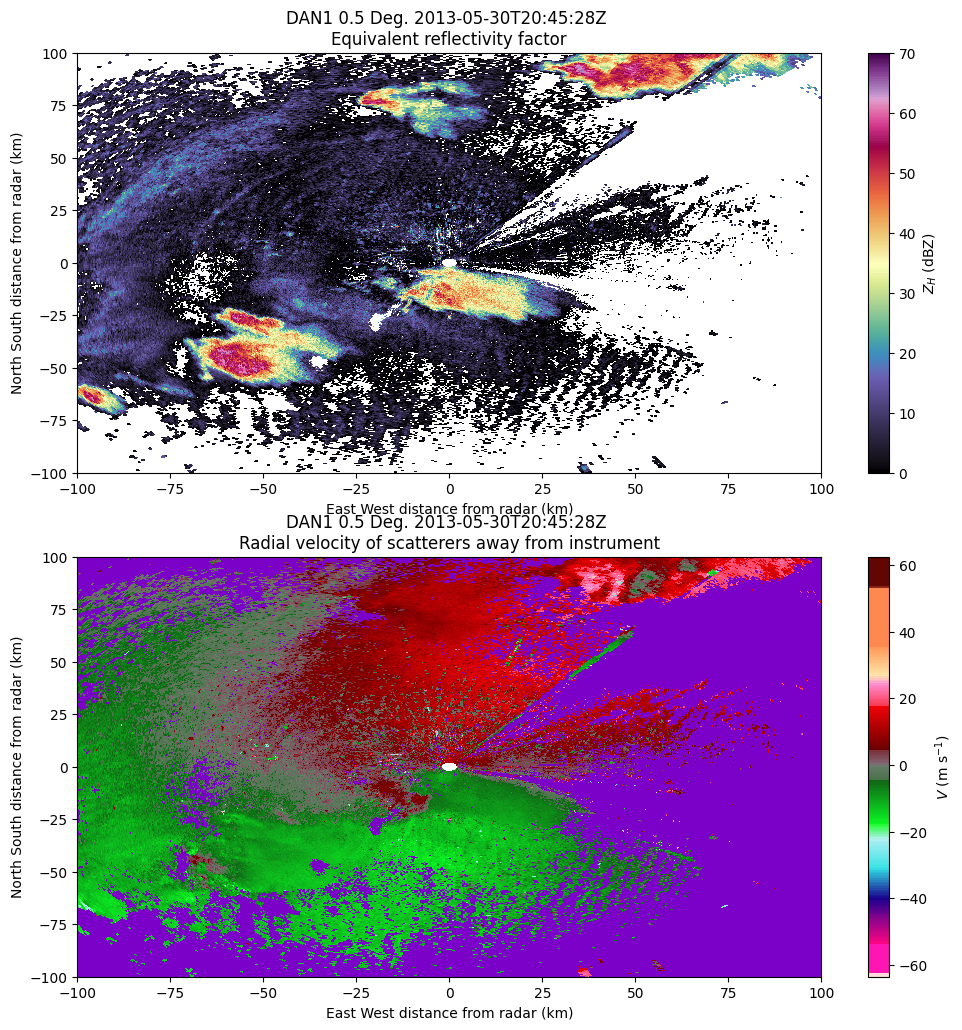

Applied gate filter in 0.1 seconds
Added KDP in 6.0 seconds
Dealiasing completed in 3.4 seconds
Sounding:      station                  validUTC  levelcode  pressure_mb  height_m  tmpc  \
0      KOUN 2013-05-30 18:00:00+00:00          4       1000.0      56.0   NaN   
1      KOUN 2013-05-30 18:00:00+00:00          9        966.0     362.0  26.8   
2      KOUN 2013-05-30 18:00:00+00:00          5        954.0     471.0  25.4   
3      KOUN 2013-05-30 18:00:00+00:00          6        937.9     609.0   NaN   
4      KOUN 2013-05-30 18:00:00+00:00          4        925.0     722.0  21.6   
..      ...                       ...        ...          ...       ...   ...   
147    KOUN 2013-05-30 18:00:00+00:00          6         11.7   30176.0   NaN   
148    KOUN 2013-05-30 18:00:00+00:00          6         11.2   30480.0   NaN   
149    KOUN 2013-05-30 18:00:00+00:00          5         10.9   30654.0 -41.3   
150    KOUN 2013-05-30 18:00:00+00:00          6         10.7   30784.0   NaN   
15

AttributeError: module 'pyart.graph' has no attribute 'cm_colorblind'

In [ ]:
### Data processing ###
radar_alias = []
archive_sites = [_expand_radar_sites(r) for r in radar_sites]
radar_alias.extend(archive_sites[i][j] for i in range(len(archive_sites)) for j in range(len(archive_sites[i]))) 
print("Radar aliases:", radar_alias)

fields_config = rpc.get_dict()

# Function to convert radar time to pandas Timestamp
def to_pd_time(time_value, time_units):
    t = num2date(time_value, time_units, only_use_cftime_datetimes=False)
    if isinstance(t, np.ndarray):
        t = t.item()

    # Fallback for cftime objects
    if not isinstance(t, datetime):
        t = datetime(t.year, t.month, t.day, t.hour, t.minute, t.second)

    # Round to nearest second
    return pd.Timestamp(t).round("s")

# Function to convert gridded data to xarray Dataset
def grid_to_xarray_dataset(grid, site, date_str, source_file):
    # Grid time (single timestamp)
    t = to_pd_time(grid.time['data'][0], grid.time['units'])

    coords = {
        "time": pd.DatetimeIndex([t]),
        "z": grid.z['data'],  # 1D array of z levels
        "y": grid.y['data'],  # 1D array of y coordinates
        "x": grid.x['data'],  # 1D array of x coordinates
    }

    keep_fields = [
        "reflectivity",
        "velocity",
        "cross_correlation_ratio",
        "specific_differential_phase",
        "corrected_velocity",
        "differential_reflectivity",
        "hsda",
        "mesh_75_mh19",
        "hdr",
        "hdr_size",
        "hca"
    ]

    data_vars = {}

    for field_name in keep_fields:
        if field_name not in grid.fields:
            print(f"Warning: {field_name} not found in grid fields. Skipping.")
            continue
        arr = np.ma.asarray(grid.fields[field_name]["data"])

        # HSDA/HCA are often integer classes; cast so NaN fill is legal
        if np.issubdtype(arr.dtype, np.integer):
            arr = arr.astype(np.float32)

        arr = arr.filled(np.nan)
        data_vars[field_name] = (("time", "z", "y", "x"), arr[np.newaxis, ...])

    ds = xr.Dataset(data_vars=data_vars, coords=coords)
    ds.attrs['site'] = site
    ds.attrs['date'] = date_str
    ds.attrs['source_file'] = source_file
    return ds

# Convert time to UTC
def _as_utc(ts):
    ts = pd.Timestamp(ts)
    if ts.tzinfo is None:
        return ts.tz_localize("UTC")
    return ts.tz_convert("UTC")

# Get scan time from radar filename (e.g., KTLX20130530_214603_V06 -> 2013-05-30 21:46:03 UTC)
def parse_scan_time_from_filename(fname):
    m = re.search(r"([A-Z0-9]{4})(\d{8})_(\d{6})", fname)
    if m is None:
        raise ValueError(f"Could not parse scan time from {fname}")
    return pd.to_datetime(m.group(2) + m.group(3), format="%Y%m%d%H%M%S", utc=True)

# Function to get radiosonde data for a given reference time and station, with caching
_raob_cache = {}
def get_radiosonde(reference_time_utc, station="KOUN", lookback_hours=36):
    RAOB_BASE = "https://mesonet.agron.iastate.edu/cgi-bin/request/raob.py"
    RAOB_COLUMNS = [
        "station", "validUTC", "levelcode", "pressure_mb", "height_m",
        "tmpc", "dwpc", "drct", "speed_kts", "bearing", "range_sm"
    ]
    
    ref = _as_utc(reference_time_utc)
    cache_key = (station, ref.floor("h"))

    if cache_key in _raob_cache:
        return _raob_cache[cache_key].copy()

    sts = ref - pd.Timedelta(hours=lookback_hours)
    params = {
        "station": station,
        "sts": sts.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "ets": ref.strftime("%Y-%m-%dT%H:%M:%SZ"),
        "dl": "yes",
    }
    url = f"{RAOB_BASE}?{urlencode(params)}"

    df = pd.read_csv(url, na_values=["M"])
    if df.empty:
        raise ValueError(f"No sounding rows for {station} up to {ref}")

    missing = [c for c in RAOB_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Unexpected RAOB format, missing columns: {missing}")

    df["validUTC"] = pd.to_datetime(df["validUTC"], utc=True, errors="coerce")
    df = df.dropna(subset=["validUTC"]).copy()

    launch_time = df.loc[df["validUTC"] <= ref, "validUTC"].max()
    if pd.isna(launch_time):
        raise ValueError(f"No sounding at/before {ref} for {station}")

    snd = df[df["validUTC"] == launch_time].copy()
    for col in ["pressure_mb", "height_m", "tmpc", "dwpc", "drct", "speed_kts", "bearing", "range_sm"]:
        snd[col] = pd.to_numeric(snd[col], errors="coerce")

    snd = snd.sort_values("height_m").reset_index(drop=True)
    _raob_cache[cache_key] = snd.copy()
    return snd

# Get isotherm height (e.g., 0°C) from radiosonde data using linear interpolation
def isotherm_height_m(snd, target_c):
    p = snd[["height_m", "tmpc"]].dropna().sort_values("height_m")
    z = p["height_m"].to_numpy(dtype=float)
    t = p["tmpc"].to_numpy(dtype=float)
    if len(z) < 2:
        return np.nan

    for i in range(len(t) - 1):
        t0, t1 = t[i], t[i + 1]
        if t0 == target_c:
            return float(z[i])
        if (t0 - target_c) * (t1 - target_c) <= 0 and t1 != t0:
            frac = (target_c - t0) / (t1 - t0)
            return float(z[i] + frac * (z[i + 1] - z[i]))

    return np.nan

# Process each date and radar separately (150-250 MB each) to avoid memory issues
for date in dates:
    print("Date: ", date)
    day_str = date.replace('-', '')

    # Get radiosonde data for this date (same for all radars)
    # df = get_radiosonde(date, site)
    # temp = df['temperature'].to_numpy()
    # height = df['height'].to_numpy()

    # Iterate through each radar site
    for site in radar_alias:
        files = sorted([f for f in os.listdir(radar_dir) if f.startswith(f"{site}{day_str}")])
        total_size = sum(os.path.getsize(os.path.join(radar_dir, f)) for f in files) / (1024 * 1024)  # Convert to MB
        print(f"Processing {len(files)} files ({total_size:.1f} MB) for {site} on {date}...")
        
        # Output directory for gridded radar data
        zarr_root = os.path.join(radar_dir, "zarr")
        os.makedirs(zarr_root, exist_ok=True)
        zarr_path = os.path.join(zarr_root, f"{site}_{day_str}_barnes2_grid.zarr")

        # Skip processing if zarr already exists
        existing_times = set()
        if os.path.exists(zarr_path):
            try:
                ds_existing = xr.open_zarr(zarr_path)
                existing_times = set(pd.to_datetime(ds_existing["time"].values).round("s"))
                ds_existing.close()
                print(f"  Found existing gridded data with {len(ds_existing.time)} time steps. Skipping gridding.")
                continue
            except Exception as e:
                print(f"  Warning: Failed to read metadata for {zarr_path}. Error: {e}")

        first_write = not os.path.exists(zarr_path)

        for i, f in enumerate(files):
            fpath = os.path.join(radar_dir, f)
            scan_time = parse_scan_time_from_filename(f)  # always defined for this file
            print(f"  - {f} ({os.path.getsize(fpath) / (1024 * 1024):.1f} MB)")
            
            # Read radar files for this site and date
            stage_t0 = time.time()
            radar = pyart.io.read(fpath)
            
            # Quick plot every Nth file
            if i % 10 == 0:
                # vel = radar.fields["velocity"]["data"]
                # for s in range(radar.nsweeps):
                #     sl = radar.get_slice(s)
                #     n_valid = np.ma.count(vel[sl, :])
                #     print(f"sweep {s:02d}: valid velocity gates = {n_valid}")

                # best_sweep = max(range(radar.nsweeps), key=lambda s: np.ma.count(vel[radar.get_slice(s), :]))
                best_sweep = 1
                display_ = pyart.graph.RadarDisplay(radar)
                
                fig, ax = plt.subplots(2, 1, figsize=(12, 12))
                display_.plot("reflectivity", best_sweep, ax=ax[0], vmin=0, vmax=70, cmap=fields_config['z']['cmap'], colorbar_label=fields_config['z']['cbar_label'])
                nyq = radar.instrument_parameters['nyquist_velocity']['data'][0]
                print(radar.fields.keys())
                print(radar.info())
                vel_valid = np.ma.compressed(radar.fields['velocity']['data'])
                print(vel_valid.min(), vel_valid.max())
                print("Nyquist velocity: ", nyq)
                display_.plot("velocity", best_sweep, ax=ax[1], vmin=fields_config['v']['vmin'], vmax=fields_config['v']['vmax'], cmap=fields_config['v']['cmap'], colorbar_label=fields_config['v']['cbar_label'])
                [display_.set_limits((default_xmin, default_xmax), (default_ymin, default_ymax), ax=ax[i]) for i in range(2)]
                fig.savefig(os.path.join(base_dir, "Figures", f"{site}_{day_str}_{f[13:19]}.png"), dpi=300, bbox_inches='tight')
                plt.show()
                plt.close(fig)

            # Apply gatefilter
            s = time.time()
            gfilter = pyart.correct.GateFilter(radar)
            gfilter.exclude_below("reflectivity", 0)
            if "cross_correlation_ratio" in radar.fields:
                gfilter.exclude_below("cross_correlation_ratio", 0.5)
            print("Applied gate filter in {:.1f} seconds".format(time.time() - s))

            ## Calculate KDP
            if 'differential_phase' in radar.fields: # skip for TOKC (single-pol)
                s = time.time()
                kdp_dict = pyart.retrieve.kdp_vulpiani(radar, gatefilter=gfilter, 
                                                        band='C' if radar.metadata.get('instrument_name', '').startswith('T') else 'S',
                                                        windsize=10, n_iter=2, interp=False)
                radar.add_field('specific_differential_phase', kdp_dict[0], replace_existing=True)
                print("Added KDP in {:.1f} seconds".format(time.time() - s))

            ## Velocity dealiasing
            s = time.time()
            nyq = radar.instrument_parameters['nyquist_velocity']['data'][0] # nyquist velocity
            if nyq == 0: # TOKC
                nyq = 22.4 # m/s
            dealiased_vel = pyart.correct.dealias_region_based(radar, vel_field='velocity', nyquist_vel=nyq, gatefilter=gfilter)
            radar.add_field('corrected_velocity', dealiased_vel, replace_existing=True)
            print("Dealiasing completed in {:.1f} seconds".format(time.time() - s))

            ## Apply HCA (needed for HSDA)
            if 'cross_correlation_ratio' in radar.fields: # only apply HCA for dual-pol radars
                s = time.time()

                # Get radiosonde data from KOUN prior to scan time
                sounding = get_radiosonde(scan_time, station="KOUN")

                # print("Sounding: ", sounding)
                # sounding.to_csv(os.path.join(base_dir, f"{site}_{day_str}_{f[13:19]}_sounding.csv"), index=False)
                
                # Sounding profile arrays
                profile = sounding[["height_m", "tmpc"]].dropna().sort_values("height_m")
                print("Profile: ", profile)
                height = profile["height_m"].to_numpy(dtype=float)
                temp = profile["tmpc"].to_numpy(dtype=float)

                # Get temperature profile from radiosonde
                num_gates = radar.range['data'].shape[0]
                num_el = radar.elevation['data'].shape[0]

                # Put range and elevation data into common 2D array
                rr = repmat(radar.range['data'], num_el, 1) / 1000 # convert to km
                el = np.transpose(repmat(radar.elevation['data'], num_gates, 1))

                # Calculate beam height for each pixel
                ht = rlib.bh_calc(rr, el)

                # Interpolate radiosonde temperature to radar beam heights
                temps = np.interp(ht, height, temp)

                # Create a new dictionary for temperature and add the field to the radar object
                temp_dict = {'data': temps}
                radar.add_field('temperature', temp_dict, replace_existing=True)            

                ## Calculate HCA using semi-supervised method (Besic et al. 2016)
                weights = np.array([1., 1., 1., 0.75, 0.5]) # Zh, ZDR, KDP, rhohv, relh (relative height)
                mass_centers = None # Centroids for each variable and class
                HCA = pyart.retrieve.hydroclass_semisupervised(radar, weights=weights, mass_centers=mass_centers,
                                                               refl_field='reflectivity', 
                                                               zdr_field='differential_reflectivity', 
                                                               kdp_field='specific_differential_phase',
                                                               rhv_field='cross_correlation_ratio',
                                                               temp_field='temperature',
                                                               temp_ref='temperature')
                radar.add_field('hca', HCA['hydro'], replace_existing=True)
                hydro_cmap = pyart.graph.cm_colorblind.HydroClass
                print("HCA classes: ", np.unique(HCA['hydro']))
                print(hydro_cmap)
                # hca_labels = ["NC", "AG", "CR", "LR", "RP", "RN", "VI", "WS", "MH", "IH/HDG"]
                print("HCA completed in {:.1f} seconds".format(time.time() - s))

                ## Calculate MESH, HSDA, and HDR for each gridded radar volume
                s = time.time()
                # Hail differential reflectivity (HDR)
                radar = hdr.pyart(
                    radar,
                    reflectivity_fname='reflectivity',
                    differential_reflectivity_fname='differential_reflectivity',
                    hdr_fname='hdr',
                    hdr_size_fname='hdr_size',
                )
                print("HDR completed in {:.1f} seconds".format(time.time() - s))

                # Hail size discrimination algorithm (HSDA)
                s = time.time()
                fz_level = isotherm_height_m(sounding, 0.0) # Freezing level height in meters from sounding
                m20_level = isotherm_height_m(sounding, -20.0) # -20 C level height in meters from sounding
                if np.isnan(fz_level) or np.isnan(m20_level):
                    print("Warning: Could not determine freezing level or -20C level from sounding. Using fallback values.")
                    fz_level, m20_level = 4000, 8000 # fallback values in meters
                
                radar = hsda.pyart(
                    radar,
                    reflectivity_fname='reflectivity',
                    differential_reflectivity_fname='differential_reflectivity',
                    cross_correlation_ratio_fname='cross_correlation_ratio',
                    radar_classification_fname='hca',
                    levels = [fz_level, m20_level],
                    hca_hail_idx=[8, 9], # "MH" and "IH/HDG" classes in the HCA output
                    hsda_fname='hsda',
                )
                print("HSDA completed in {:.1f} seconds".format(time.time() - s))

                # Maximum estimated size of hail (MESH) (Murillo and Homeyer (2019) formulation)
                s = time.time()
                mesh_ppi_added = False
                ray_counts = [radar.get_slice(s).stop - radar.get_slice(s).start for s in range(radar.nsweeps)]
                if len(set(ray_counts)) != 1:
                    print(f"Skipping mesh_ppi (variable rays per sweep): {ray_counts}")
                else:
                    radar = mesh_ppi.pyart(
                        radar,
                        reflectivity_fname='reflectivity',
                        temp_levels=[fz_level, m20_level],
                        radar_band='C' if radar.metadata.get('instrument_name', '').startswith('T') else 'S',
                        ke_fname="ke", # Hail kinetic energy
                        shi_fname="shi", # Severe hail index
                        mesh_fname="mesh_75_mh19", # Maximum estimated size of hail (MH19)
                        posh_fname="posh", # Probability of severe hail
                    )
                    mesh_ppi_added = True
                print("MESH completed in {:.1f} seconds".format(time.time() - s))

            # Two-pass Barnes interpolation scheme
            s = time.time()
            grid_barnes2 = pyart.map.grid_from_radars(
                radar,
                grid_shape=grid_shape,
                gridding_algo = 'map_gates_to_grid',
                weighting_function = 'barnes2',
                gatefilters = gfilter,
                roi_func = roi,
                constant_roi = roi,
                grid_limits=(zlims, ylims, xlims))
            print("Gridding completed in {:.1f} seconds.".format(time.time() - s))
            
            # Calculate gridded MESH if PPI MESH fails
            if not mesh_ppi_added:
                s = time.time()
                meshgrid = mesh_grid.main(grid_barnes2,
                                          dbz_fname='reflectivity',
                                          levels=[fz_level, m20_level],
                                          radar_band='C' if radar.metadata.get('instrument_name', '').startswith('T') else 'S',
                                          ke_fname="ke", # Hail kinetic energy
                                          shi_fname="shi", # Severe hail index
                                          mesh_fname="mesh_75_mh19", # Maximum estimated size of hail (MH19)
                                          posh_fname="posh", # Probability of severe hail
                                          correct_cband_refl=False)
                grid_barnes2.add_field('mesh_75_mh19', meshgrid['mesh_75_mh19'], replace_existing=True)
                print("Gridded MESH completed in {:.1f} seconds.".format(time.time() - s))
                
            if 'cross_correlation_ratio' in grid_barnes2.fields: # only plot for dual-pol radars
                if i % 10 == 0:
                    # Quick plot of gridded data (Z, V, and CC [top]; KDP, V_corrected, and ZDR [middle]; and HDR, HSDA, and MESH [bottom])
                    fig, axes = plt.subplots(4, 3, figsize=(24, 24), layout='constrained')
                    [X, Y] = np.meshgrid(grid_barnes2.x['data'], grid_barnes2.y['data'])
                    
                    Zb = grid_barnes2.fields['reflectivity']['data']
                    Vb = grid_barnes2.fields['velocity']['data']
                    CCb = grid_barnes2.fields['cross_correlation_ratio']['data']
                    KDPb = grid_barnes2.fields['specific_differential_phase']['data']
                    Vcb = grid_barnes2.fields['corrected_velocity']['data']
                    ZDRb = grid_barnes2.fields['differential_reflectivity']['data']

                    # Hail fields
                    HDRsb = grid_barnes2.fields['hdr_size']['data']
                    HSDAb = grid_barnes2.fields['hsda']['data']
                    MESHb = grid_barnes2.fields['mesh_75_mh19']['data']

                    # HCA
                    HCAb = grid_barnes2.fields['hca']['data']

                    fields = [(Zb, 'z'), (Vb, 'v'), (CCb, 'rho'), (KDPb, 'kdp'), (Vcb, 'v'), (ZDRb, 'zdr'), (HDRsb, 'hdr_size'), (HSDAb, 'hsda'), (MESHb, 'mesh_75_mh19'), (HCAb, 'hca')]
                    height = 2 # km AGL

                    # Top panel
                    for panel_idx, (field, field_name) in enumerate(fields[0:3]):
                        p = axes[0, panel_idx].pcolormesh(X, Y, np.squeeze(field[height,:,:]), vmin=fields_config[field_name]['vmin'], vmax=fields_config[field_name]['vmax'], cmap=fields_config[field_name]['cmap'])
                        axes[0, panel_idx].set_title(f"{fields_config[field_name]['title']} ({height} km AGL)")
                        plt.colorbar(p, ax=axes[0, panel_idx], label=fields_config[field_name]['cbar_label'], extend='both')
                    
                    # Middle panel
                    for panel_idx, (field, field_name) in enumerate(fields[3:6]):
                        p = axes[1, panel_idx].pcolormesh(X, Y, np.squeeze(field[height,:,:]), vmin=fields_config[field_name]['vmin'], vmax=fields_config[field_name]['vmax'], cmap=fields_config[field_name]['cmap'])
                        axes[1, panel_idx].set_title(f"{fields_config[field_name]['title']} ({height} km AGL)")
                        plt.colorbar(p, ax=axes[1, panel_idx], label=fields_config[field_name]['cbar_label'], extend='both')

                    # Bottom panel
                    for panel_idx, (field, field_name) in enumerate(fields[6:9]):
                        p = axes[2, panel_idx].pcolormesh(X, Y, np.squeeze(field[height,:,:]), vmin=fields_config[field_name]['vmin'], vmax=fields_config[field_name]['vmax'], cmap=fields_config[field_name]['cmap'])
                        axes[2, panel_idx].set_title(f"{fields_config[field_name]['title']} ({height} km AGL)")
                        cbar = plt.colorbar(p, ax=axes[2, panel_idx], label=fields_config[field_name]['cbar_label'], extend='both')

                        # Custom categorical ticks for HSDA
                        if field_name == 'hsda':
                            cbar.set_ticks(fields_config[field_name]['cbar_ticks'])
                            cbar.set_ticklabels(fields_config[field_name]['cbar_tick_labels'])

                    # HCA
                    hca_labels = ["NC", "AG", "CR", "LR", "RP", "RN", "VI", "WS", "MH", "IH/HDG"]
                    
                    boundaries = np.arange(-0.5, len(hca_labels))
                    norm = mcolors.BoundaryNorm(boundaries, 256)

                    p = axes[3, 1].pcolormesh(X, Y, np.squeeze(HCAb[height,:,:]), norm=norm, cmap=hydro_cmap) # gist_ncar
                    axes[3, 1].set_title(f"{"Hydrometeor Classification Algorithm (Besic)"} ({height} km AGL)")
                    cbar = plt.colorbar(p, ax=axes[3, 1], label='', extend='both')
                    cbar.set_ticks(np.arange(len(hca_labels)))
                    cbar.set_ticklabels(hca_labels)

                    plot_config(axes, tick_spacing_km=10)
                    plot_scan_time = to_pd_time(grid_barnes2.time['data'][0], grid_barnes2.time['units'])
                    plt.suptitle(f"{site} at {plot_scan_time} - Gridded Fields (Barnes2)", fontsize=18, weight='bold')
                    fig.savefig(os.path.join(base_dir, "Figures", f"{site}_{day_str}_gridded_fields_{f[13:19]}.png"), dpi=300, bbox_inches='tight')
                    plt.show()
                    plt.close(fig)

            # Append to Zarr store
            ds = grid_to_xarray_dataset(grid_barnes2, site, date, fpath)
            ds_time = scan_time.tz_convert("UTC").tz_localize(None).round("s")
            ds = ds.assign_coords(time=pd.DatetimeIndex([ds_time]))

            print("ds: ", ds)
            print(ds.time.values)

            if ds_time in existing_times:
                print(f"  Time {ds_time} already exists in Zarr store. Skipping append.")
            else:
                if first_write:
                    ds.to_zarr(zarr_path, mode='w')
                    first_write = False
                    print(f"  Created new Zarr store and added data for time {ds_time}.")
                else:
                    ds.to_zarr(zarr_path, mode='a', append_dim='time')
                    print(f"  Appended data for time {ds_time} to {zarr_path}.")
            
            print("Total file time: {:.1f} seconds".format(time.time() - stage_t0))
            
            # Cleanup
            if 'specific_differential_phase' in grid_barnes2.fields:
                del kdp_dict
            del radar, gfilter, dealiased_vel, grid_barnes2, ds
            gc.collect()
            
print(f"Processed radars for {len(dates)} dates.")

In [ ]:
### Create hail swaths for each date
for date in dates:
    print("Creating hail swath for date: ", date)
    day_str = date.replace('-', '')
    zarr_file = [f for f in os.listdir(os.path.join(radar_dir, "zarr")) if f.startswith(f"{site}_{day_str}") and f.endswith("_barnes2_grid.zarr")][0]

    if not zarr_file:
        print(f"No gridded files found for {date}. Skipping.")
        continue

    # Output directory for swath data
    swath_dir = os.path.join(radar_dir, "zarr", "swaths")
    os.makedirs(swath_dir, exist_ok=True)
    swath_path = os.path.join(swath_dir, f"{site}_{day_str}_hail_swath.zarr")

    # Skip if swath already exists
    if os.path.exists(swath_path):
        print(f"  Found existing swath data at {swath_path}. Skipping swath creation.")
        continue

    zarr_path = os.path.join(radar_dir, "zarr", zarr_file)
    print(f"  Reading gridded data from {zarr_path}...")
    ds = xr.open_zarr(zarr_path)

    fields = ['reflectivity', 'hdr_size', 'hsda', 'mesh_75_mh19']
    ds_swath = ds[fields].copy()

    # Create swaths by taking max over time and height dimensions
    swaths = ds_swath.max(dim=["time", "z"], skipna=True)

    print(swaths)

    # Plot swaths (2x2 figure with Z, HDR, HSDA, and MESH)
    fig, axes = plt.subplots(2, 2, figsize=(24, 24), layout='constrained')
    X, Y = np.meshgrid(ds_swath.x, ds_swath.y)

    fields = [(swaths.reflectivity, 'z'), (swaths.hdr_size, 'hdr_size'), (swaths.hsda, 'hsda'), (swaths.mesh_75_mh19, 'mesh_75_mh19')]
    # Top panel
    for panel_idx, (field, field_name) in enumerate(fields[0:2]):
        p = axes[0, panel_idx].pcolormesh(X, Y, field, vmin=fields_config[field_name]['vmin'], vmax=fields_config[field_name]['vmax'], cmap=fields_config[field_name]['cmap'])
        axes[0, panel_idx].set_title(f"{fields_config[field_name]['title']}")
        plt.colorbar(p, ax=axes[0, panel_idx], label=fields_config[field_name]['cbar_label'], extend='both')
    
    # Bottom panel
    for panel_idx, (field, field_name) in enumerate(fields[2:4]):
        p = axes[1, panel_idx].pcolormesh(X, Y, field, vmin=fields_config[field_name]['vmin'], vmax=fields_config[field_name]['vmax'], cmap=fields_config[field_name]['cmap'])
        axes[1, panel_idx].set_title(f"{fields_config[field_name]['title']}")
        cbar = plt.colorbar(p, ax=axes[1, panel_idx], label=fields_config[field_name]['cbar_label'], extend='both')

        # Custom categorical ticks for HSDA
        if field_name == 'hsda':
            cbar.set_ticks(fields_config[field_name]['cbar_ticks'])
            cbar.set_ticklabels(fields_config[field_name]['cbar_tick_labels'])

    plot_config(axes, tick_spacing_km=10)
    plt.suptitle(f"Swaths for {site} on {date}", fontsize=18, weight='bold')
    plt.show()
    plt.close(fig)
    


In [ ]:
### Retrieve DDA winds
